# 07 — Faz 5b: Renk Zenginleştirmesi (`set_colors.csv`)

**Amaç:** `inventory_parts.csv` (~133 MB) ile `colors.csv`'yi birleştirip **set başına renk özet
tablosu** üretmek. Bu tablo Bölüm 2 EDA'sında (renk çeşitliliği fiyatla ilişkili mi?) ve ileride
Bölüm 3'te (renk paleti evrimi) kullanılacak.

Bir setin renk dağılımı **iki kaynağın birleşimi** — [01_data_quality_check.ipynb](01_data_quality_check.ipynb)
§10'da `num_parts` için doğrulanan zincirin aynısı:

```
set parçaları    : set_num --(en güncel envanter)--> inventory_id --(inventory_parts, is_spare=False)--> color_id
minifig parçaları: set_num --(en güncel envanter)--> inventory_id --(inventory_minifigs: fig_num × adet)
                   --> minifigin kendi en güncel envanteri --(inventory_parts, is_spare=False)--> color_id
                                                                         ↓
                                         colors.csv → name, is_trans → tek birleşik renk dağılımı
```

Envanter eşleştirmesi `src/rebrickable.py`'deki `latest_inventory()` fonksiyonunda (01 §10 ve 03 ile aynı mantık).

**Kararlar:**
- **Spare parçalar hariç** (`is_spare=False`) — hem set hem minifig envanterinde. §10'da `num_parts`'ın
  spare parçaları içermediği doğrulandı; setin "asıl" görünümünü temsil etmiyorlar.
- **Minifig parçaları dahil.** Setin kendi envanteri minifiglerin parçalarını içermiyor (onlar ayrı
  `fig-...` envanterlerinde); bunlar hariç tutulunca minifigli setlerin renk çeşitliliği sistematik olarak
  düşük çıkıyordu (bkz. §6). Birleşik dağılım §10'daki `num_parts` tanımıyla da birebir örtüşüyor.
- **Birim = parça adedi** (`quantity` toplamı), satır sayısı değil. Minifig parçaları setteki minifig
  adediyle çarpılıyor (aynı figürden 3 tane varsa parçaları 3 kez sayılır).

In [1]:
import resource
import sys
import time

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, "../src")
from rebrickable import latest_inventory, read_inventory_parts

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RAW = "../data/raw"
PROCESSED = "../data/processed"


def peak_rss_mb() -> float:
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024 / 1024  # macOS: byte cinsinden

## 1. Veriyi oku

In [2]:
t0 = time.perf_counter()
inventory_parts = read_inventory_parts(RAW)
read_seconds = time.perf_counter() - t0

colors = pd.read_csv(f"{RAW}/colors.csv", usecols=["id", "name", "rgb", "is_trans"])
inventories = pd.read_csv(f"{RAW}/inventories.csv")
inventory_minifigs = pd.read_csv(f"{RAW}/inventory_minifigs.csv")
sets_clean = pd.read_csv(f"{PROCESSED}/sets_clean.csv")

print(f"inventory_parts.csv   : {len(inventory_parts):,} satır — {read_seconds:.2f} sn, "
      f"bellekte {inventory_parts.memory_usage(deep=True).sum() / 1e6:.0f} MB")
print(f"colors.csv            : {len(colors):,} renk ({colors['is_trans'].sum()} şeffaf)")
print(f"inventories.csv       : {len(inventories):,} envanter")
print(f"inventory_minifigs.csv: {len(inventory_minifigs):,} satır")
print(f"sets_clean.csv        : {len(sets_clean):,} set ({sets_clean['is_analysis_ready'].sum():,} analiz-hazır)")
print(f"Süreç tepe belleği şu ana kadar: {peak_rss_mb():.0f} MB")

inventory_parts.csv   : 1,556,894 satır — 0.37 sn, bellekte 17 MB
colors.csv            : 275 renk (46 şeffaf)
inventories.csv       : 47,339 envanter
inventory_minifigs.csv: 25,809 satır
sets_clean.csv        : 18,899 set (18,190 analiz-hazır)
Süreç tepe belleği şu ana kadar: 200 MB


**Bellek notu:** Dosyanın tamamı (`img_url` ve `part_num` dahil) okunduğunda ~293 MB bellek tutuyor;
`read_inventory_parts()` sadece gereken 4 kolonu dar tiplerle (`int32`/`int16`/`bool`) okuyarak bunu
~17 MB'a indiriyor. 24 GB RAM'li makinede chunk'lı okumaya gerek kalmadı.

## 2. `set_num` ↔ `inventory_id` (en güncel version)

In [3]:
latest = latest_inventory(inventories)

n_multi_version = (inventories.groupby("set_num").size() > 1).sum()
print(f"Birden fazla envanter versiyonu olan set: {n_multi_version:,} / {inventories['set_num'].nunique():,}")
print(f"En güncel envanter tablosu: {len(latest):,} satır (03 notebook'u ile aynı olmalı: 45,403)")
assert latest["set_num"].is_unique
assert len(latest) == 45_403

Birden fazla envanter versiyonu olan set: 1,280 / 45,403
En güncel envanter tablosu: 45,403 satır (03 notebook'u ile aynı olmalı: 45,403)


## 3. Parça–renk tabloları (spare hariç)

### 3a. Setin kendi parçaları

In [4]:
color_lookup = colors.rename(columns={"id": "color_id", "name": "color_name"})[["color_id", "color_name", "is_trans"]]
non_spare = inventory_parts[~inventory_parts["is_spare"]]

n_spare = inventory_parts["is_spare"].sum()
set_parts = (
    non_spare.merge(latest, on="inventory_id", how="inner")  # eski envanter versiyonlarının satırları düşer
    .merge(color_lookup, on="color_id", how="left")
    [["set_num", "color_name", "is_trans", "quantity"]]
)

print(f"Spare olarak çıkarılan satır: {n_spare:,} ({n_spare / len(inventory_parts):.1%})")
print(f"Set parçası satırı: {len(set_parts):,} — {set_parts['quantity'].sum():,} parça")
assert set_parts["color_name"].notna().all(), "colors.csv'de karşılığı olmayan color_id var"
print("✅ Tüm color_id'ler colors.csv'de eşleşti")

Spare olarak çıkarılan satır: 110,454 (7.1%)
Set parçası satırı: 1,327,254 — 4,624,111 parça
✅ Tüm color_id'ler colors.csv'de eşleşti


### 3b. Setteki minifiglerin parçaları

In [5]:
fig_links = (
    inventory_minifigs.merge(latest, on="inventory_id")  # setin en güncel envanterindeki minifigler
    [["set_num", "fig_num", "quantity"]].rename(columns={"quantity": "fig_qty"})
    .merge(latest.rename(columns={"set_num": "fig_num", "inventory_id": "fig_inventory_id"}), on="fig_num")
)
fig_parts = (
    fig_links.merge(non_spare.rename(columns={"inventory_id": "fig_inventory_id"}), on="fig_inventory_id")
    .merge(color_lookup, on="color_id", how="left")
)
fig_parts["quantity"] = fig_parts["quantity"] * fig_parts["fig_qty"]  # aynı figürden n adet → parçaları n kez
fig_parts = fig_parts[["set_num", "color_name", "is_trans", "quantity"]]

n_linked_figs = inventory_minifigs.merge(latest, on="inventory_id")["fig_num"].nunique()
print(f"Setlere bağlı farklı minifig: {n_linked_figs:,}; envanteri bulunan: {fig_links['fig_num'].nunique():,}")
print(f"Minifig parçası satırı: {len(fig_parts):,} — {fig_parts['quantity'].sum():,} parça, {fig_parts['set_num'].nunique():,} sette")
assert fig_parts["color_name"].notna().all()

Setlere bağlı farklı minifig: 16,778; envanteri bulunan: 16,778
Minifig parçası satırı: 106,181 — 118,548 parça, 9,402 sette


## 4. Set başına renk metrikleri (birleşik dağılım)

Set parçaları ve minifig parçaları **tek bir renk dağılımında** birleştiriliyor, metrikler bunun üzerinden:

- `n_unique_colors`: farklı renk sayısı (`[Unknown]` rengi de bir renk olarak sayılıyor — çok nadir)
- `dominant_color_name`: toplam `quantity`'si en yüksek renk (eşitlikte alfabetik ilk renk, tekrarlanabilirlik için)
- `dominant_color_share`: dominant rengin setin toplam parça adedi içindeki payı (%)
- `n_trans_parts`: şeffaf (`is_trans=True`) parça adedi

Aynı fonksiyon §6'daki öncesi/sonrası karşılaştırması için yalnızca set parçalarına da uygulanıyor.

In [6]:
def color_metrics(parts: pd.DataFrame) -> pd.DataFrame:
    by_color = parts.groupby(["set_num", "color_name", "is_trans"], as_index=False)["quantity"].sum()
    totals = by_color.groupby("set_num").agg(total_parts=("quantity", "sum"), n_unique_colors=("color_name", "nunique"))
    n_trans = by_color[by_color["is_trans"]].groupby("set_num")["quantity"].sum().rename("n_trans_parts")
    dominant = (
        by_color.sort_values(["set_num", "quantity", "color_name"], ascending=[True, False, True])
        .drop_duplicates("set_num")
        .set_index("set_num")[["color_name", "quantity"]]
        .rename(columns={"color_name": "dominant_color_name", "quantity": "dominant_qty"})
    )
    out = totals.join(dominant).join(n_trans)
    out["n_trans_parts"] = out["n_trans_parts"].fillna(0).astype(int)
    out["dominant_color_share"] = (out["dominant_qty"] / out["total_parts"] * 100).round(2)
    return out.reset_index()


set_colors = color_metrics(pd.concat([set_parts, fig_parts], ignore_index=True))
set_colors_sets_only = color_metrics(set_parts)  # yalnızca karşılaştırma için (önceki tanım)

is_fig_row = set_colors["set_num"].str.startswith("fig-")
print(f"Renk verisi hesaplanan set_num: {len(set_colors):,} "
      f"({(~is_fig_row).sum():,} set + {is_fig_row.sum():,} minifig envanteri)")
print(f"Yalnızca set parçalarıyla (önceki tanım): {len(set_colors_sets_only):,}")
set_colors.describe()

Renk verisi hesaplanan set_num: 37,292 (20,070 set + 17,222 minifig envanteri)
Yalnızca set parçalarıyla (önceki tanım): 37,009


,total_parts,n_unique_colors,dominant_qty,n_trans_parts,dominant_color_share
count,37292.000000,37292.000000,37292.000000,37292.000000,37292.000000
mean,127.176311,7.445270,40.325110,5.061434,43.165776
std,389.416292,7.473047,135.518169,20.362242,21.826674
min,1.000000,1.000000,1.000000,0.000000,3.330000
25%,4.000000,3.000000,2.000000,0.000000,25.000000
50%,7.000000,4.000000,4.000000,0.000000,39.780000
75%,70.000000,9.000000,25.000000,2.000000,50.000000
max,11695.000000,58.000000,7543.000000,1137.000000,100.000000


**Doğrulama — `num_parts` ile tutarlılık:** §10'a göre `num_parts = spare-olmayan parçalar + minifig
parçaları`. Birleşik `total_parts` bu tanımın ta kendisi, dolayısıyla `num_parts` ile **birebir eşit**
olmalı.

In [7]:
check = sets_clean.merge(set_colors[["set_num", "total_parts"]], on="set_num", how="inner")
exact = check["total_parts"] == check["num_parts"]
print(f"total_parts == num_parts: {exact.mean():.2%} ({exact.sum():,} / {len(check):,} set)")
print(f"total_parts >  num_parts: {(check['total_parts'] > check['num_parts']).mean():.2%}")
print(f"total_parts <  num_parts: {(check['total_parts'] < check['num_parts']).mean():.2%}")

total_parts == num_parts: 99.41% (18,781 / 18,893 set)
total_parts >  num_parts: 0.38%
total_parts <  num_parts: 0.22%


## 5. Kaydet

In [8]:
OUT_COLS = ["set_num", "n_unique_colors", "dominant_color_name", "dominant_color_share", "n_trans_parts"]
out_path = f"{PROCESSED}/set_colors.csv"
set_colors[OUT_COLS].to_csv(out_path, index=False)
print(f"Kaydedildi: {out_path} — {len(set_colors):,} satır, kolonlar: {OUT_COLS}")
set_colors[OUT_COLS].head()

Kaydedildi: ../data/processed/set_colors.csv — 37,292 satır, kolonlar: ['set_num', 'n_unique_colors', 'dominant_color_name', 'dominant_color_share', 'n_trans_parts']


,set_num,n_unique_colors,dominant_color_name,dominant_color_share,n_trans_parts
0,0003977811-1,3,Red,60.00,0
1,001-1,5,White,39.53,0
2,0011-2,5,Black,25.00,0
3,0012-1,3,Red,66.67,0
4,0013-1,3,White,66.67,0


## 6. `sets_clean.csv` ile LEFT JOIN testi (kalıcı ekleme değil)

Sadece `is_analysis_ready == True` olan setler için kaç tanesinin renk verisine sahip olduğu
raporlanıyor; `sets_clean.csv` değiştirilmiyor.

In [9]:
ready = sets_clean[sets_clean["is_analysis_ready"]]
joined = ready.merge(set_colors[OUT_COLS], on="set_num", how="left")
assert len(joined) == len(ready), "Join satır sayısını değiştirdi"

matched = joined["n_unique_colors"].notna()
matched_before = ready["set_num"].isin(set_colors_sets_only["set_num"])
print(f"Analiz-hazır set: {len(ready):,}")
print(f"Renk verisi eşleşen: {matched.sum():,} ({matched.mean():.2%})  — yalnızca set parçalarıyla: {matched_before.sum():,} ({matched_before.mean():.2%})")
print(f"Eşleşmeyen: {(~matched).sum():,}")
joined.loc[~matched, ["set_num", "name", "year", "theme_name", "num_parts", "minifig_count"]]

Analiz-hazır set: 18,190
Renk verisi eşleşen: 18,185 (99.97%)  — yalnızca set parçalarıyla: 18,018 (99.05%)
Eşleşmeyen: 5


,set_num,name,year,theme_name,num_parts,minifig_count
4718,3549-2,Practice Shooting (Kabaya Co-Pack),2003,Basketball,4,0
4722,3550-2,Jump and Shoot (Kabaya Co-Pack),2003,Basketball,3,0
8297,5003488-1,EV3 Space Challenge and Activity Pack,2014,Mindstorms,1,0
16689,9371-1,Town Vehicles,1999,Town,34,0
18072,TOYFAIR2005-2,Toy Fair 2005 Star Wars V.I.P. Gala,2005,Star Wars,28,0


### 6a. Öncesi / sonrası — minifig parçaları eklenince ne değişti?

Karşılaştırma, **her iki tanımda da renk verisi olan** ve **en az bir minifig içeren** analiz-hazır
setler üzerinden (minifigsiz setlerde iki tanım zaten aynı).

In [10]:
cmp = (
    ready[["set_num", "name", "year", "theme_name", "num_parts", "minifig_count"]]
    .merge(set_colors_sets_only[["set_num", "n_unique_colors", "dominant_color_name"]], on="set_num")
    .merge(set_colors[["set_num", "n_unique_colors", "dominant_color_name"]], on="set_num", suffixes=("_before", "_after"))
)
cmp["delta"] = cmp["n_unique_colors_after"] - cmp["n_unique_colors_before"]
fig_sets = cmp[cmp["minifig_count"] > 0]
no_fig_sets = cmp[cmp["minifig_count"] == 0]

assert (no_fig_sets["delta"] == 0).all(), "Minifigsiz bir sette renk sayısı değişmiş"
print(f"Minifig içeren set: {len(fig_sets):,}")
print(f"n_unique_colors medyanı: önce {fig_sets['n_unique_colors_before'].median():.0f} → sonra {fig_sets['n_unique_colors_after'].median():.0f}")
print(f"n_unique_colors ortalaması: önce {fig_sets['n_unique_colors_before'].mean():.2f} → sonra {fig_sets['n_unique_colors_after'].mean():.2f}")
print(f"Renk sayısı artan set: {(fig_sets['delta'] > 0).mean():.1%} (artanlarda medyan +{fig_sets.loc[fig_sets['delta'] > 0, 'delta'].median():.0f})")
print(f"Dominant rengi değişen set: {(fig_sets['dominant_color_name_before'] != fig_sets['dominant_color_name_after']).mean():.1%}")
print(f"Minifigsiz {len(no_fig_sets):,} sette değişiklik: yok ✅")

Minifig içeren set: 8,166
n_unique_colors medyanı: önce 12 → sonra 13
n_unique_colors ortalaması: önce 13.18 → sonra 15.39
Renk sayısı artan set: 86.6% (artanlarda medyan +2)
Dominant rengi değişen set: 13.8%
Minifigsiz 9,852 sette değişiklik: yok ✅


In [11]:
# En çok minifigli seti olan temalar
top_themes = fig_sets["theme_name"].value_counts().head(8).index
theme_cmp = (
    fig_sets[fig_sets["theme_name"].isin(top_themes)]
    .groupby("theme_name")
    .agg(
        set_sayisi=("set_num", "size"),
        medyan_minifig=("minifig_count", "median"),
        medyan_renk_once=("n_unique_colors_before", "median"),
        medyan_renk_sonra=("n_unique_colors_after", "median"),
        medyan_artis=("delta", "median"),
        artan_set_orani=("delta", lambda d: round((d > 0).mean() * 100, 1)),
    )
    .sort_values("set_sayisi", ascending=False)
)
theme_cmp

,set_sayisi,medyan_minifig,medyan_renk_once,medyan_renk_sonra,medyan_artis,artan_set_orani
theme_name,,,,,,
Star Wars,632,3.0,12.0,15.0,2.0,92.7
Ninjago,552,2.0,9.0,11.0,2.0,85.5
Friends,457,2.0,23.0,26.0,3.0,99.3
Classic Town,355,1.0,8.0,9.0,1.0,66.5
City,173,3.0,17.0,20.0,2.0,93.1
Police,173,2.0,14.0,16.0,2.0,90.2
Minecraft,164,2.0,20.0,22.0,2.5,95.1
Harry Potter,156,4.0,19.0,22.0,2.5,97.4


In [12]:
# Örnek: Star Wars — en çok minifig içeren 8 set
(
    fig_sets[fig_sets["theme_name"] == "Star Wars"]
    .sort_values(["minifig_count", "num_parts"], ascending=False)
    .head(8)[["set_num", "name", "year", "num_parts", "minifig_count", "n_unique_colors_before", "n_unique_colors_after", "delta"]]
)

,set_num,name,year,num_parts,minifig_count,n_unique_colors_before,n_unique_colors_after,delta
13401,75290-1,Mos Eisley Cantina,2020,3187,21,31,35,4
14186,7662-1,Trade Federation MTT,2007,1326,21,9,13,4
13332,75222-1,Betrayal at Cloud City,2018,2812,20,32,35,3
13184,75086-1,Battle Droid Troop Carrier,2015,565,15,12,13,1
13541,75418-1,Star Wars Advent Calendar 2025,2025,263,14,22,25,3
13483,75365-1,Yavin 4 Rebel Base,2023,1067,12,26,32,6
13551,75435-1,Battle of Felucia Separatist MTT,2025,976,12,21,24,3
13164,75058-1,MTT,2014,954,12,19,22,3


## 7. Kısa EDA — `n_unique_colors` yıllara göre trend var mı?

Bölüm 3'ün erken bir önizlemesi, sadece sağlık kontrolü: veri makul görünüyor mu, kullanılabilir mi?
**Dikkat:** setler zamanla büyüdü (Bölüm 1), daha çok parça doğal olarak daha çok renk demek. Bu
yüzden trend **set büyüklüğü sabit tutularak** da hesaplanıyor. Korelasyonlar hem güncel (minifig dahil)
hem önceki (yalnızca set parçaları) tanımla yan yana veriliyor.

In [13]:
size_bins = [0, 100, 500, float("inf")]
size_labels = ["≤100 parça", "101–500 parça", ">500 parça"]


def spearman_table(colors_df: pd.DataFrame) -> pd.Series:
    d = ready.merge(colors_df[["set_num", "n_unique_colors"]], on="set_num")
    d["size_tier"] = pd.cut(d["num_parts"], bins=size_bins, labels=size_labels)
    rho = {"tüm setler": d["year"].corr(d["n_unique_colors"], method="spearman")}
    for tier, g in d.groupby("size_tier", observed=True):
        rho[tier] = g["year"].corr(g["n_unique_colors"], method="spearman")
    return pd.Series(rho)


rho_cmp = pd.DataFrame({
    "önce (yalnızca set parçaları)": spearman_table(set_colors_sets_only),
    "sonra (minifig dahil)": spearman_table(set_colors),
})
rho_cmp["fark"] = rho_cmp.iloc[:, 1] - rho_cmp.iloc[:, 0]
print("Spearman ρ (yıl ~ n_unique_colors), analiz-hazır setler")
rho_cmp.round(3)

Spearman ρ (yıl ~ n_unique_colors), analiz-hazır setler


,önce (yalnızca set parçaları),sonra (minifig dahil),fark
tüm setler,0.435,0.475,0.040
≤100 parça,0.268,0.371,0.103
101–500 parça,0.558,0.559,0.002
>500 parça,0.564,0.542,-0.022


In [14]:
eda = joined[matched].copy()
eda["n_unique_colors"] = eda["n_unique_colors"].astype(int)
eda["size_tier"] = pd.cut(eda["num_parts"], bins=size_bins, labels=size_labels)

yearly = eda.groupby("year")["n_unique_colors"].agg(
    n="size", median="median", q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75)
)
years = range(eda["year"].min(), eda["year"].max() + 1)
yearly = yearly[yearly["n"] >= 20].reindex(years)  # az setli yıllar gürültülü; boş yıl = çizgide kopukluk

tier_yearly = (
    eda.groupby(["size_tier", "year"], observed=True)["n_unique_colors"]
    .agg(["size", "median"])
    .query("size >= 20")
    .reset_index()
)

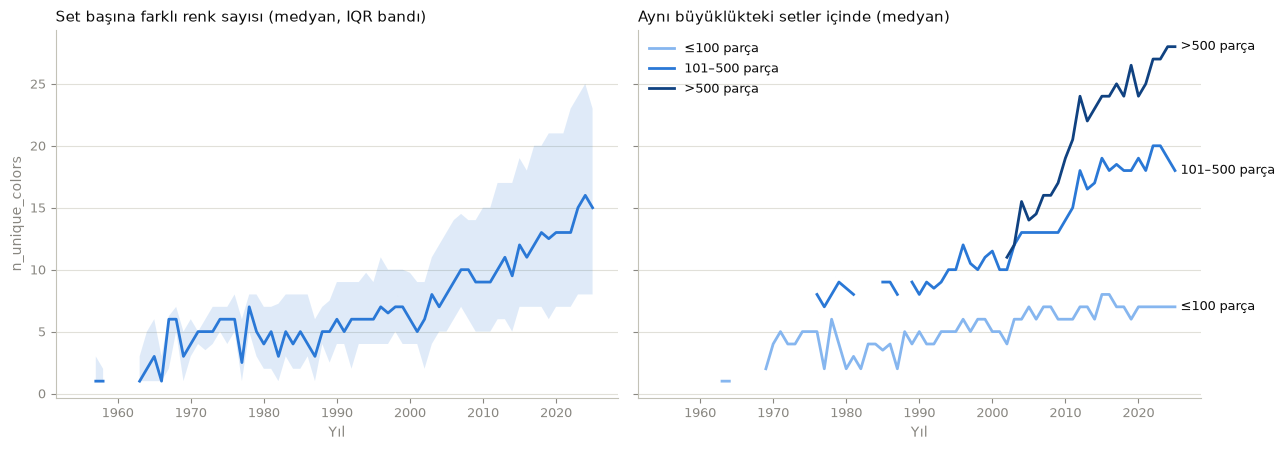

In [15]:
INK, MUTED, GRID, BASE = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
BLUE = "#2a78d6"
TIER_COLORS = dict(zip(size_labels, ["#86b6ef", "#2a78d6", "#104281"]))  # tek ton, sıralı (açık→koyu)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax in axes:
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_color(BASE)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.set_xlabel("Yıl", color=MUTED)

ax = axes[0]
ax.fill_between(yearly.index, yearly["q1"], yearly["q3"], color=BLUE, alpha=0.15, linewidth=0)
ax.plot(yearly.index, yearly["median"], color=BLUE, linewidth=2)
ax.set_title("Set başına farklı renk sayısı (medyan, IQR bandı)", color=INK, fontsize=11, loc="left")
ax.set_ylabel("n_unique_colors", color=MUTED)

ax = axes[1]
for tier in size_labels:
    d = tier_yearly[tier_yearly["size_tier"] == tier].set_index("year")["median"]
    last_year = d.index.max()
    d = d.reindex(range(d.index.min(), last_year + 1))  # 20'den az setli yıllar çizgide boşluk olarak kalır
    ax.plot(d.index, d.values, color=TIER_COLORS[tier], linewidth=2, label=tier)
    ax.annotate(tier, (last_year, d.loc[last_year]), xytext=(4, 0), textcoords="offset points",
                color=INK, fontsize=9, va="center")
ax.set_title("Aynı büyüklükteki setler içinde (medyan)", color=INK, fontsize=11, loc="left")
ax.legend(frameon=False, fontsize=9, labelcolor=INK, loc="upper left")

fig.tight_layout()
plt.show()

In [16]:
decade = (eda["year"] // 10 * 10).rename("decade")
eda.groupby([decade, "size_tier"], observed=True)["n_unique_colors"].median().unstack().loc[1970:]

size_tier,≤100 parça,101–500 parça,>500 parça
decade,,,
1970,4.0,7.0,7.0
1980,3.0,8.0,9.0
1990,5.0,10.0,11.0
2000,6.0,12.0,14.0
2010,7.0,17.0,23.0
2020,7.0,19.0,27.0


In [17]:
print(f"Toplam çalışma: tepe bellek {peak_rss_mb():.0f} MB")

Toplam çalışma: tepe bellek 546 MB


## Özet

- **`data/processed/set_colors.csv`: 37.292 satır** — set parçaları + minifig parçaları birleşik renk
  dağılımından. 17.222'si minifig (`fig-...`) envanteri; ileride minifig renk analizi için bilerek
  tutuldu, `sets_clean` ile join'de zaten düşüyorlar.
- **Eşleşme:** analiz-hazır 18.190 setin **18.185'i (%99,97)** renk verisine sahip (yalnızca set
  parçalarıyla %99,05'ti). Kalan 5 setin envanterinde ne parça ne minifig kaydı var (co-pack, aktivite paketi ve alt setlerden oluşan paketler).
- **Tutarlılık:** birleşik `total_parts`, setlerin %99,41'inde `num_parts` ile birebir eşit — §10'daki
  `num_parts = set parçaları + minifig parçaları` bulgusu tüm veride doğrulandı.
- **Öncesi/sonrası (minifig içeren 8.166 set):** `n_unique_colors` medyanı **12 → 13**, ortalaması
  **13,2 → 15,4**; setlerin %86,6'sında renk sayısı arttı (artanlarda medyan +2), %13,8'inde dominant
  renk değişti. Minifigsiz setlerde hiçbir şey değişmedi. Etki minifig-yoğun temalarda belirgin:
  **Star Wars medyanı 12 → 15** (setlerin %92,7'si), Friends 23 → 26 (%99,3), Harry Potter 19 → 22.
- **Korelasyon bulgusu sağlam:** yıl ~ renk sayısı Spearman ρ genel **0,435 → 0,475**; 101–500 parça
  0,558 → 0,559 ve >500 parça 0,564 → 0,542 (neredeyse aynı). Tek belirgin değişim **≤100 parça
  diliminde 0,268 → 0,371**: küçük setlerde minifigler toplam parçanın büyük kısmını oluşturuyor ve
  zamanla daha renkli hale gelmişler. "Renk çeşitliliği set büyüklüğünden bağımsız olarak zamanla
  artıyor" sonucu değişmedi, küçük setler için güçlendi.
- **Performans:** 133 MB'lık dosya 4 kolon + dar tiplerle ~0,4 sn'de, 17 MB bellekle okunuyor; tüm
  notebook ~545 MB tepe bellekle birkaç saniyede çalışıyor. Chunk'lı okumaya gerek olmadı.